In [1]:
%pip install requests pandas matplotlib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
import io

import boto3
import pandas as pd

PROJECT_BUCKET = "weather-classification-tf-662832404229-2605"
COUNTS_PREFIX = "results/weather_type_counts/station_id=GDN_01/"

s3 = boto3.client("s3")

response = s3.list_objects_v2(
    Bucket=PROJECT_BUCKET,
    Prefix=COUNTS_PREFIX,
)

csv_keys = [
    obj["Key"]
    for obj in response.get("Contents", [])
    if obj["Key"].endswith(".csv") and "part-" in obj["Key"]
]

csv_keys

['results/weather_type_counts/station_id=GDN_01/part-00000-906a823b-b997-4488-8f87-7a4f85006c36-c000.csv',
 'results/weather_type_counts/station_id=GDN_01/part-00001-906a823b-b997-4488-8f87-7a4f85006c36-c000.csv',
 'results/weather_type_counts/station_id=GDN_01/part-00002-906a823b-b997-4488-8f87-7a4f85006c36-c000.csv',
 'results/weather_type_counts/station_id=GDN_01/part-00003-906a823b-b997-4488-8f87-7a4f85006c36-c000.csv']

In [3]:
frames = []

for key in csv_keys:
    obj = s3.get_object(
        Bucket=PROJECT_BUCKET,
        Key=key,
    )

    part_df = pd.read_csv(io.BytesIO(obj["Body"].read()))
    frames.append(part_df)

counts = pd.concat(frames, ignore_index=True)

counts = counts.sort_values("count", ascending=False)

counts

,primary_weather_type,count
0,normal,240
1,windy,121
2,rainy,67
3,sunny,41
4,cloudy,27
5,storm-risk,4


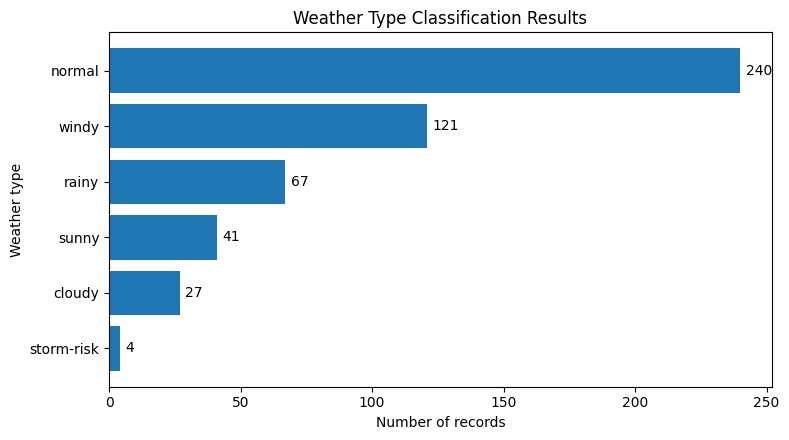

In [4]:
import matplotlib.pyplot as plt

counts_sorted = counts.sort_values("count", ascending=True)

plt.figure(figsize=(8, 4.5))

bars = plt.barh(
    counts_sorted["primary_weather_type"],
    counts_sorted["count"],
)

plt.title("Weather Type Classification Results")
plt.xlabel("Number of records")
plt.ylabel("Weather type")

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 2,
        bar.get_y() + bar.get_height() / 2,
        str(int(width)),
        va="center",
    )

plt.tight_layout()
plt.show()